In [1]:
#imports all libraries and functions needed for the model
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import librosa
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import TimeDistributed, GlobalAveragePooling2D, Activation
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Reshape
from tensorflow.keras.applications import VGG16
from tensorflow.keras.regularizers import l2

In [2]:
#Puts ratings into a dictionary
def read_ratings(file_path):
  ratings = {}
  with open(file_path, 'r') as file:
    for line in file:
      parts = line.strip().split()
      clip_num = parts[0]
      scores = [float(x) for x in parts[1:]]
      ratings[clip_num] = scores
  return ratings

In [3]:
#loads the ground training ground truth ratings
base = "/content/drive/MyDrive/FinalDataSet"

train_gt = f"{base}/train_ground_truth.txt"
valid_gt = f"{base}/valid_ground_truth.txt"
test_gt = f"{base}/test_ground_truth.txt"

train_ratings = read_ratings(train_gt)
valid_ratings = read_ratings(valid_gt)
test_ratings = read_ratings(test_gt)

print("Train samples: ", len(train_ratings))
print("Validation samples: ", len(valid_ratings))
print("Test samples: ", len(test_ratings))


Train samples:  84
Validation samples:  15
Test samples:  15


In [4]:
import librosa
import numpy as np
import os
#extracts the spectrogram
def extract_spectrogram(y, sr, max_len=128):
    # Convert audio to Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Standardize length
    if S_dB.shape[1] < max_len:
        S_dB = np.pad(S_dB, ((0, 0), (0, max_len - S_dB.shape[1])), mode='constant')
    else:
        S_dB = S_dB[:, :max_len]
    return S_dB

#Augmentation functions
def pitch_shift(audio, sr):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)

def add_noise(audio):
  noise = np.random.randn(len(audio))
  return audio + 0.005 * noise

def augment_audio(audio, sr):
    return [
        audio,
        pitch_shift(audio, sr),
        add_noise(audio)
    ]

In [5]:
import cv2
#function to build the dataset with the augmented data and spectrogram
def build_dataset(folder, ratings, sr = 22050, time_steps = 3):#10):
  x = []
  y = []

  for file in os.listdir(folder):
    if file.endswith(".wav"):
      clip = file.split(".")[0]

      if clip in ratings:
        #load raw data
        path = os.path.join(folder, file)
        audio, _ = librosa.load(path, sr = sr)

        labels = ratings[clip]

        #augmentation step
        augmented_audio = augment_audio(audio, sr)

        #extract features (spectrogram)
        for aug in augmented_audio:
          spec = extract_spectrogram(aug, sr)
          step = spec.shape[1]

          sequence = []

          spec = cv2.resize(spec, (224, 224))
          spec = np.stack([spec]*3, axis=-1)
          sequence = [spec] * time_steps

          # only add full sequences
          if len(sequence) == time_steps:
              x.append(np.array(sequence))
              y.append(labels)

  return np.array(x), np.array(y)

In [9]:
#bulids the data set
x_train, y_train = build_dataset(base, train_ratings)
x_valid, y_valid = build_dataset(base, valid_ratings)
x_test, y_test = build_dataset(base, test_ratings)

print("Train set: ", x_train.shape)
print("Validation set: ", x_valid.shape)
print("Test set: ", x_test.shape)

/tmp/ipykernel_913/1163662195.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr = sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_913/1163662195.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr = sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Train set:  (252, 3, 224, 224, 3)
Validation set:  (45, 3, 224, 224, 3)
Test set:  (45, 3, 224, 224, 3)


In [10]:
#Loads the pretrained VGG16 without top layers
base_model = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)
#Freeze weights
base_model.trainable = False

print(base_model.summary())

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [ ]:
print(x_train.shape)
print(y_train.shape)

(252, 3, 224, 224, 3)
(252, 5)


In [11]:
#Normaization
mean = np.mean(x_train, axis = 0)
std = np.std(x_train, axis = 0)

x_train = (x_train - mean) / std
x_valid = (x_valid - mean) / std
x_test = (x_test - mean) / std


In [12]:
SS_AI = Sequential()

# CNN feature extractor applied per frame
SS_AI.add(TimeDistributed(base_model, input_shape=(None, 224, 224, 3)))

# flatten CNN output (7x7x512 → 25088)
SS_AI.add(TimeDistributed(GlobalAveragePooling2D()))


SS_AI.add(Bidirectional(LSTM(128, return_sequences = True)))
SS_AI.add(Dropout(0.3))

SS_AI.add(Bidirectional(LSTM(128, return_sequences = False)))
SS_AI.add(Dropout(0.3))

SS_AI.add(Dense(256, kernel_regularizer = l2(0.001)))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(256))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(256))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(256))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(256))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(128))
SS_AI.add(Activation('relu'))

SS_AI.add(Dense(5))
SS_AI.add(Activation('sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
SS_AI.compile(optimizer = Adam(learning_rate = 0.001),
              loss = 'mse',
              metrics = ['mse'])
history = SS_AI.fit(
    x_train, y_train,
    epochs = 100,
    batch_size = 16,
    validation_data = (x_valid, y_valid),
    shuffle = True
)

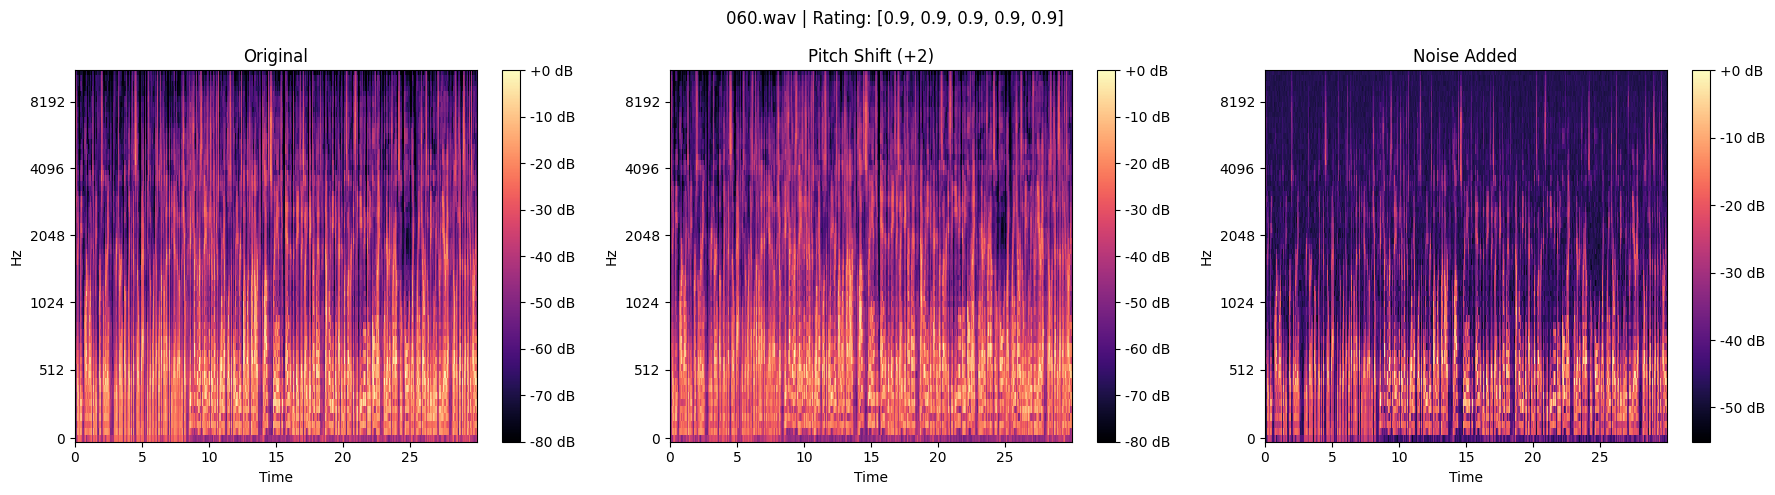

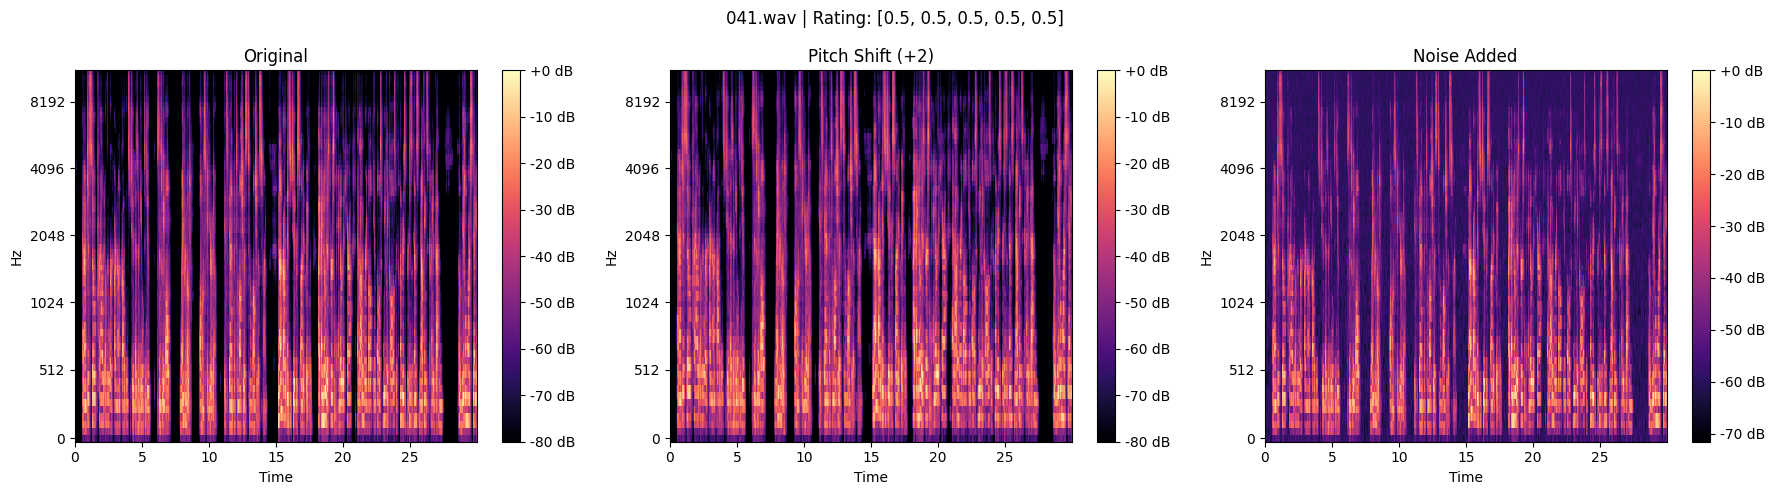

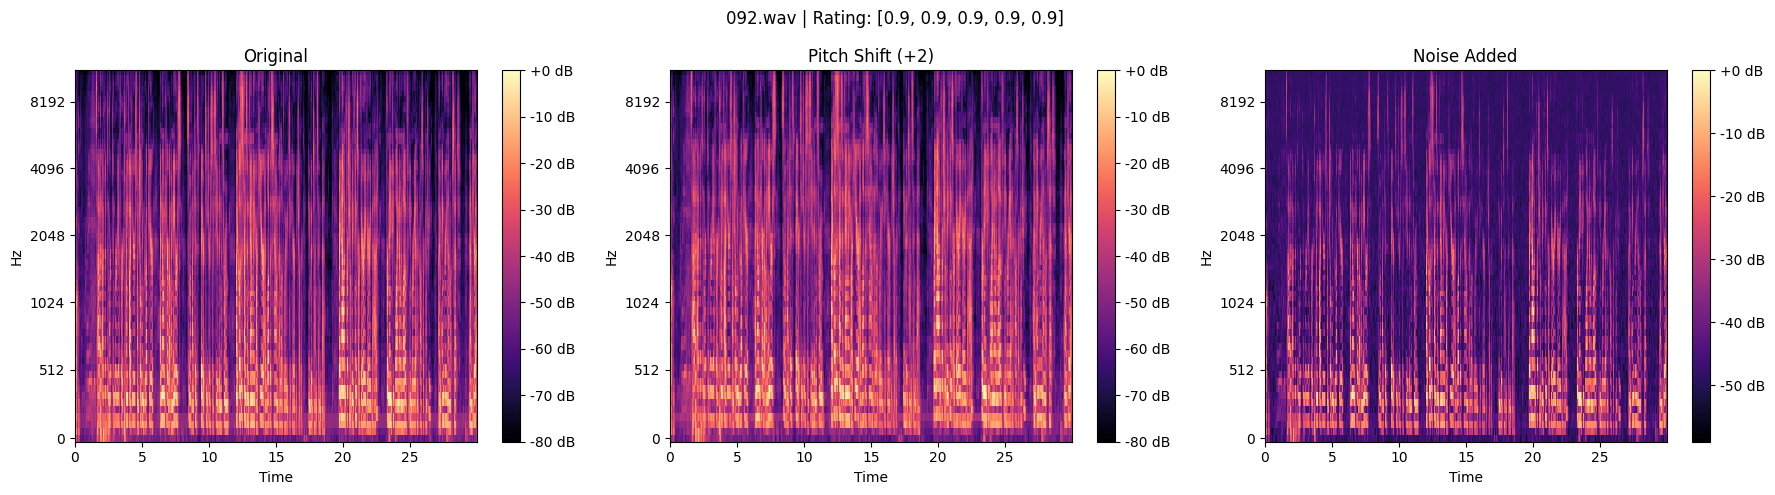

In [13]:
#Vizualization of the spectrograms for presentation purposes
import os
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def display_spectrograms(folder, ratings, num_samples=3, sr=22050):

    # collect valid files
    files = [
        f for f in os.listdir(folder)
        if f.endswith(".wav") and f.split(".")[0] in ratings
    ]

    if not files:
        print("No audio files found.")
        return

    selected = random.sample(files, min(num_samples, len(files)))

    for file in selected:
        clip_id = file.split(".")[0]
        path = os.path.join(folder, file)

        audio, _ = librosa.load(path, sr=sr)

        # --- augmentations ---
        audio_original = audio
        audio_pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
        audio_noise = audio + 0.005 * np.random.randn(len(audio))

        specs = [
            ("Original", audio_original),
            ("Pitch Shift (+2)", audio_pitch),
            ("Noise Added", audio_noise)
        ]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{file} | Rating: {ratings[clip_id]}")

        for i, (title, aud) in enumerate(specs):
            spec = librosa.feature.melspectrogram(y=aud, sr=sr, n_mels=64)
            spec_db = librosa.power_to_db(spec, ref=np.max)

            librosa.display.specshow(
                spec_db,
                sr=sr,
                x_axis='time',
                y_axis='mel',
                ax=axes[i]
            )

            axes[i].set_title(title)
            fig.colorbar(axes[i].collections[0], ax=axes[i], format="%+2.0f dB")

        plt.tight_layout()
        plt.show()
display_spectrograms(base, train_ratings, num_samples=3)

In [ ]:
#Displays the augmented audio for presentation purposes only
import os
import random
import numpy as np
import librosa
from IPython.display import Audio, display

def display_audio_augmentations(folder, ratings, num_samples=3, sr=22050):

    if not ratings:
        print("No ratings provided.")
        return

    # get valid files
    files = [
        f for f in os.listdir(folder)
        if f.endswith(".wav") and f.split(".")[0] in ratings
    ]

    if not files:
        print("No audio files found.")
        return

    selected = random.sample(files, min(num_samples, len(files)))

    for file in selected:
        clip_id = file.split(".")[0]
        path = os.path.join(folder, file)

        audio, _ = librosa.load(path, sr=sr)

        print(f"\n=== {file} | Rating: {ratings[clip_id]} ===")

        # --- Original ---
        print("Original")
        display(Audio(audio, rate=sr))

        # --- Pitch shift ---
        audio_pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
        print("Pitch Shift (+2)")
        display(Audio(audio_pitch, rate=sr))

        # --- Noise ---
        noise = 0.005 * np.random.randn(len(audio))
        audio_noise = audio + noise
        print("Noise Injection")
        display(Audio(audio_noise, rate=sr))
display_audio_augmentations(base, train_ratings, num_samples=3)

Output hidden; open in https://colab.research.google.com to view.

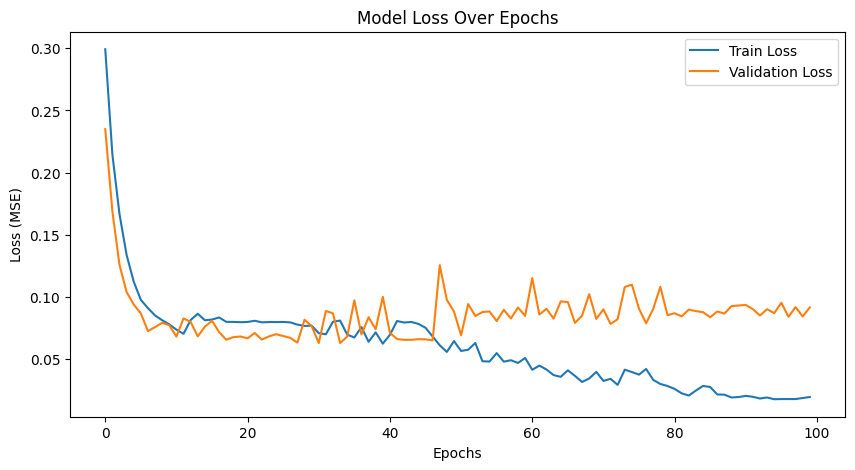

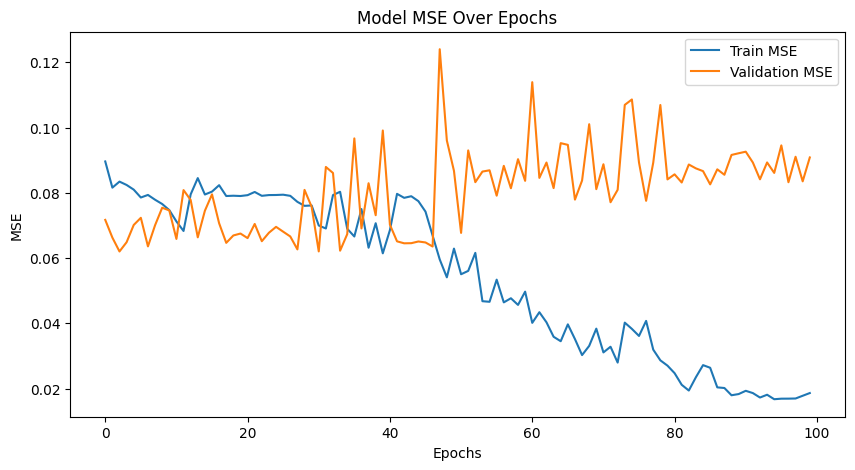

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):

    # --- Loss ---
    plt.figure(figsize=(10,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

    # --- MSE ---
    plt.figure(figsize=(10,5))
    plt.plot(history.history['mse'], label='Train MSE')
    plt.plot(history.history['val_mse'], label='Validation MSE')
    plt.title('Model MSE Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

plot_training_history(history)

In [16]:
predictions = SS_AI.predict(x_test)

i = random.randint(0, len(x_test) - 1)

print("Index:", i)
print("Predicted:", predictions[i])
print("Ground Truth:", y_test[i])

SS_AI.save_weights("SS_AI.weights.h5")

2/2 ━━━━━━━━━━━━━━━━━━━━ 86s 23s/step
Index: 42
Predicted: [0.49963313 0.49939102 0.49974605 0.49937633 0.4996035 ]
Ground Truth: [0.8 0.9 0.8 0.5 0.8]


In [14]:
import matplotlib.pyplot as plt
import numpy as np


# Flatten for overall view
y_true_flat = y_test.flatten()
y_pred_flat = predictions.flatten()


plt.figure(figsize=(6,6))
plt.scatter(y_true_flat, y_pred_flat, alpha=0.5)


# diagonal reference line
min_val = min(y_true_flat.min(), y_pred_flat.min())
max_val = max(y_true_flat.max(), y_pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')


plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Predicted vs Ground Truth")
plt.show()


NameError: name 'predictions' is not defined

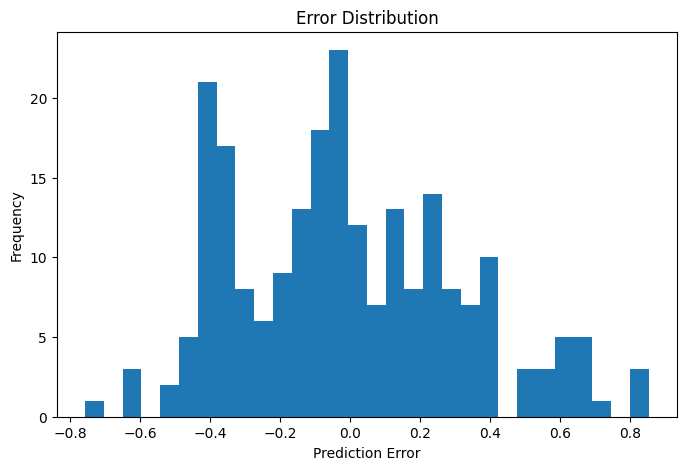

In [ ]:
errors = predictions - y_test


plt.figure(figsize=(8,5))
plt.hist(errors.flatten(), bins=30)


plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

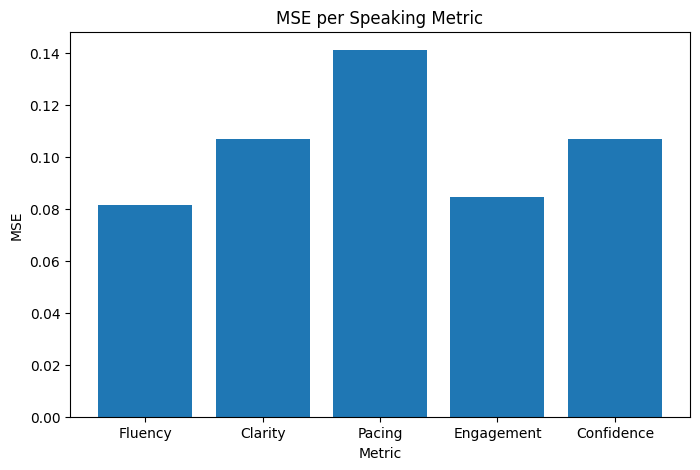

In [ ]:
mse_per_metric = np.mean((predictions - y_test) ** 2, axis=0)


metrics = ["Fluency", "Clarity", "Pacing", "Engagement", "Confidence"]


plt.figure(figsize=(8,5))
plt.bar(metrics, mse_per_metric)


plt.title("MSE per Speaking Metric")
plt.ylabel("MSE")
plt.xlabel("Metric")
plt.show()


In [ ]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# System Configuration based on V2_LSTM_Training_Model
MAX_LEN = 100
N_MFCC = 13
HZ = 16000
METRICS = ["Fluency", "Clarity", "Pacing", "Engagement", "Confidence"]

# Define Colors class for console output
class Colors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    END = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

def build_inference_engine(weights_path="speaksmart_model.h5"):
    """
    Constructs the LSTM neural network using current project architecture.
    """
    model = Sequential([
        Input(shape=(MAX_LEN, N_MFCC)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(5, activation='sigmoid')
    ])

    if os.path.exists(weights_path):
        model.load_weights(weights_path)
    return model

def get_feedback(metric, score):
    """
    Generates concise feedback based on performance thresholds.
    """
    if score >= 0.7:
        return f"{Colors.OKGREEN}Excellent performance.{Colors.END}"
    elif score >= 0.4:
        return f"{Colors.WARNING}Consistent. Room to grow.{Colors.END}"
    else:
        return f"{Colors.FAIL}Focus here next session.{Colors.END}"

def analyze_existing_wav(file_path):
    """
    Processes an audio file and displays an interactive results dashboard.
    """
    clean_path = file_path.strip()

    if not os.path.exists(clean_path):
        print(f"\n{Colors.FAIL}[ERROR] File not found: {clean_path}{Colors.END}")
        return

    print(f"\n{Colors.OKCYAN}{Colors.BOLD}>>> ANALYZING SESSION: {os.path.basename(clean_path)}{Colors.END}")

    try:
        # 1. Feature Extraction
        # Use librosa to load the audio and extract MFCC features
        signal, _ = librosa.load(clean_path, sr=HZ)
        mfccs = librosa.feature.mfcc(y=signal, sr=HZ, n_mfcc=N_MFCC)

        if mfccs.shape[1] < MAX_LEN:
            pad_width = MAX_LEN - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :MAX_LEN]

        input_data = mfccs.T.reshape(1, MAX_LEN, N_MFCC)

        # 2. Inference
        engine = build_inference_engine()
        results = engine.predict(input_data, verbose=0)[0]

        # 3. Visual Dashboard
        print("\n" + "═" * 60)
        print(f"{Colors.BOLD}   SPEAKSMART AI PERFORMANCE REPORT{Colors.END}")
        print("═" * 60)

        for i, name in enumerate(METRICS):
            score = results[i]
            color = Colors.OKGREEN if score >= 0.7 else Colors.WARNING if score >= 0.4 else Colors.FAIL

            # Create progress bar
            bar_length = 20
            filled_length = int(bar_length * score)
            bar = color + "█" * filled_length + Colors.END + "░" * (bar_length - filled_length)

            feedback = get_feedback(name, score)
            print(f" {name:12} | {score:.4f} | {bar} | {feedback}")

        print("═" * 60)
        print(f"{Colors.OKCYAN}Analysis Complete. {Colors.END}\n")

    except Exception as e:
        print(f"{Colors.FAIL}[CRITICAL ERROR] {str(e)}{Colors.END}")

if __name__ == "__main__":
    # Update this path to target your specific audio file
    TARGET_WAV = "/content/drive/MyDrive/FinalDataSet/111.wav"
    analyze_existing_wav(TARGET_WAV)


>>> ANALYZING SESSION: 111.wav


/tmp/ipykernel_5352/1985193515.py:71: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(clean_path, sr=HZ)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



════════════════════════════════════════════════════════════
   SPEAKSMART AI PERFORMANCE REPORT
════════════════════════════════════════════════════════════
 Fluency      | 0.4344 | ████████░░░░░░░░░░░░ | Consistent. Room to grow.
 Clarity      | 0.4294 | ████████░░░░░░░░░░░░ | Consistent. Room to grow.
 Pacing       | 0.4343 | ████████░░░░░░░░░░░░ | Consistent. Room to grow.
 Engagement   | 0.4953 | █████████░░░░░░░░░░░ | Consistent. Room to grow.
 Confidence   | 0.5119 | ██████████░░░░░░░░░░ | Consistent. Room to grow.
════════════════════════════════════════════════════════════
Analysis Complete. 

